--- 1. Loading and Preprocessing MNIST Dataset ---
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


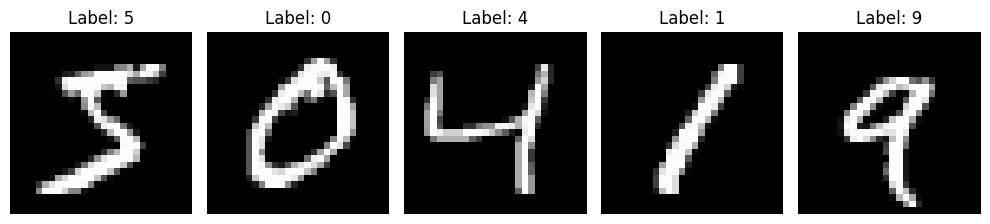


--- 2. Building the Neural Network ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


--- 3. Training the Model ---
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9124 - loss: 0.3027 - val_accuracy: 0.9595 - val_loss: 0.1377
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9634 - loss: 0.1241 - val_accuracy: 0.9720 - val_loss: 0.0970
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9746 - loss: 0.0852 - val_accuracy: 0.9715 - val_loss: 0.0988
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9806 - loss: 0.0639 - val_accuracy: 0.9772 - val_loss: 0.0825
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9842 - loss: 0.0508 - val_accuracy: 0.9768 - val_loss: 0.0805
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9877 - loss: 0.0404 - val_accuracy: 0.9768 - val_loss: 0.0811
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9898 - loss: 0.0324 - val_accuracy: 0.9765 - val_loss: 0.0826
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9913 - 

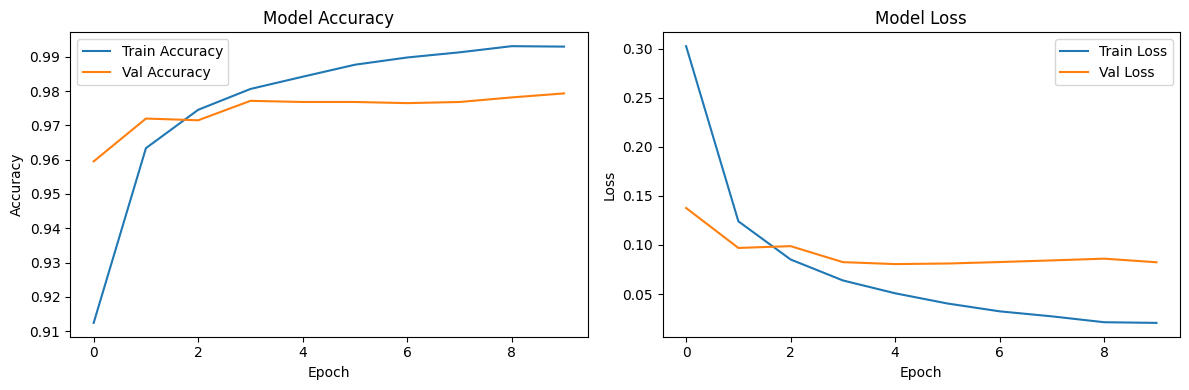


--- 4. Evaluating performance on Test Dataset ---
Test Accuracy: 0.9740
Test Loss: 0.0918
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


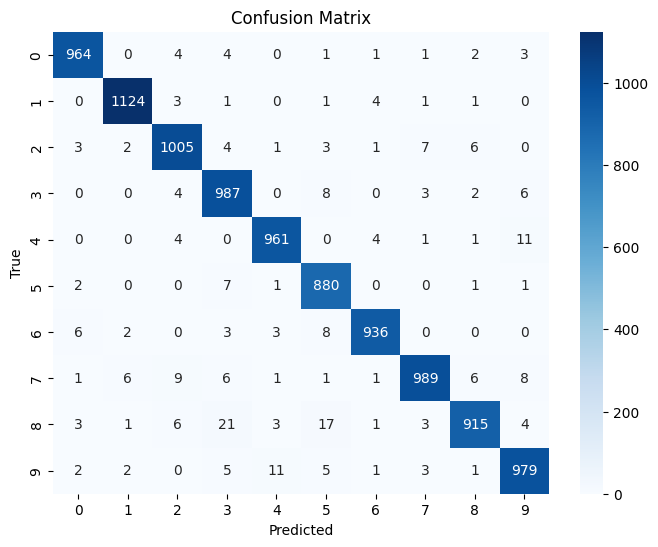

Accuracy for digit 0: 98.37%
Accuracy for digit 1: 99.03%
Accuracy for digit 2: 97.38%
Accuracy for digit 3: 97.72%
Accuracy for digit 4: 97.86%
Accuracy for digit 5: 98.65%
Accuracy for digit 6: 97.70%
Accuracy for digit 7: 96.21%
Accuracy for digit 8: 93.94%
Accuracy for digit 9: 97.03%

The model struggles the most with digit: 8 (Accuracy: 93.94%)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Load and Preprocess the MNIST Dataset
print("--- 1. Loading and Preprocessing MNIST Dataset ---")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

# Convert labels to one-hot encoded format
num_classes = 10
y_train_onehot = keras.utils.to_categorical(y_train, num_classes)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes)

# Display sample images with their labels
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# 2. Build a Fully Connected Neural Network
print("\n--- 2. Building the Neural Network ---")
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_cross_entropy' if hasattr(keras.losses, 'categorical_cross_entropy') else 'categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# 3. Train the Neural Network
print("\n--- 3. Training the Model ---")
history = model.fit(
    x_train_norm,
    y_train_onehot,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Plot loss and accuracy trends
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Evaluate the Model's Performance
print("\n--- 4. Evaluating performance on Test Dataset ---")
test_loss, test_acc = model.evaluate(x_test_norm, y_test_onehot, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Get predictions
y_pred_prob = model.predict(x_test_norm)
y_pred = np.argmax(y_pred_prob, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Identify which digits the model struggles with most
diagonal = np.diag(cm)
row_sums = cm.sum(axis=1)
class_accuracy = diagonal / row_sums
for i, acc in enumerate(class_accuracy):
    print(f"Accuracy for digit {i}: {acc*100:.2f}%")

struggling_digit = np.argmin(class_accuracy)
print(f"\nThe model struggles the most with digit: {struggling_digit} (Accuracy: {class_accuracy[struggling_digit]*100:.2f}%)")